# Tesla Deliveries — End-to-End ML Pipeline
**Dataset:** `tesla_deliveries_dataset_2015_2025.csv` · 2,640 records · 12 features · 2015–2025  
**Target:** `Estimated_Deliveries`  
**Pipeline stages:** Data Loading → EDA → Preprocessing → Feature Engineering → Regression Modeling → Hyperparameter Tuning → Time Series Forecasting

---

## 0 · Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

## 1 · Data Loading & Initial Inspection

In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print(f"Shape  : {df.shape}")
print(f"Memory : {df.memory_usage(deep=True).sum()/1e3:.1f} KB")
print()
df.head()

Shape  : (2640, 12)
Memory : 345.4 KB



,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print("── Data Types & Null Check ──")
info = pd.DataFrame({
    'dtype':   df.dtypes,
    'nulls':   df.isnull().sum(),
    'unique':  df.nunique(),
    'sample':  df.iloc[0]
})
print(info.to_string())

── Data Types & Null Check ──
                        dtype  nulls  unique                sample
Year                    int64      0      11                  2023
Month                   int64      0      12                     5
Region                    str      0       4                Europe
Model                     str      0       5               Model S
Estimated_Deliveries    int64      0    2401                 17646
Production_Units        int64      0    2430                 17922
Avg_Price_USD         float64      0    2638              92874.27
Battery_Capacity_kWh    int64      0       5                   120
Range_km                int64      0     219                   704
CO2_Saved_tons        float64      0    2599               1863.42
Source_Type               str      0       3  Interpolated (Month)
Charging_Stations       int64      0    2389                 12207


In [4]:
print("── Descriptive Statistics ──")
df.describe(include='all').T

── Descriptive Statistics ──


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,2640.0,NaN,NaN,NaN,2020.0,3.162877,2015.0,2017.0,2020.0,2023.0,2025.0
Month,2640.0,NaN,NaN,NaN,6.5,3.452707,1.0,3.75,6.5,9.25,12.0
Region,2640,4,Europe,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,2640,5,Model S,528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated_Deliveries,2640.0,NaN,NaN,NaN,9922.199621,3935.950093,48.0,7292.0,9857.0,12510.25,25704.0
Production_Units,2640.0,NaN,NaN,NaN,10655.847348,4260.600858,50.0,7828.25,10546.5,13469.0,28939.0
Avg_Price_USD,2640.0,NaN,NaN,NaN,84907.34033,20123.258036,50003.7,67726.365,85058.51,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,NaN,NaN,NaN,87.05947,20.836265,60.0,75.0,82.0,100.0,120.0
Range_km,2640.0,NaN,NaN,NaN,500.257576,120.868549,330.0,418.0,470.0,586.25,719.0
CO2_Saved_tons,2640.0,NaN,NaN,NaN,744.076989,353.221224,3.07,499.62,699.515,943.765,2548.55


## 2 · Exploratory Data Analysis (EDA)

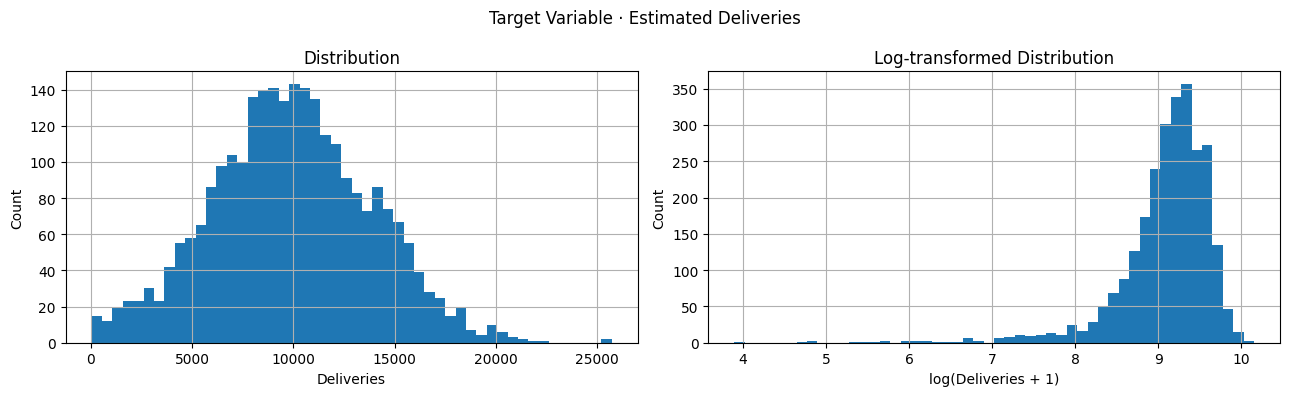

Skewness : 0.088
Mean     : 9,922
Std      : 3,936


In [5]:
# ── 2.1 Distribution of target ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Target Variable · Estimated Deliveries')

axes[0].hist(df['Estimated_Deliveries'], bins=50)
axes[0].set_title('Distribution'); axes[0].set_xlabel('Deliveries'); axes[0].set_ylabel('Count')
axes[0].grid(True)

axes[1].hist(np.log1p(df['Estimated_Deliveries']), bins=50)
axes[1].set_title('Log-transformed Distribution'); axes[1].set_xlabel('log(Deliveries + 1)'); axes[1].set_ylabel('Count')
axes[1].grid(True)

plt.tight_layout()
plt.show()
print(f"Skewness : {df['Estimated_Deliveries'].skew():.3f}")
print(f"Mean     : {df['Estimated_Deliveries'].mean():,.0f}")
print(f"Std      : {df['Estimated_Deliveries'].std():,.0f}")

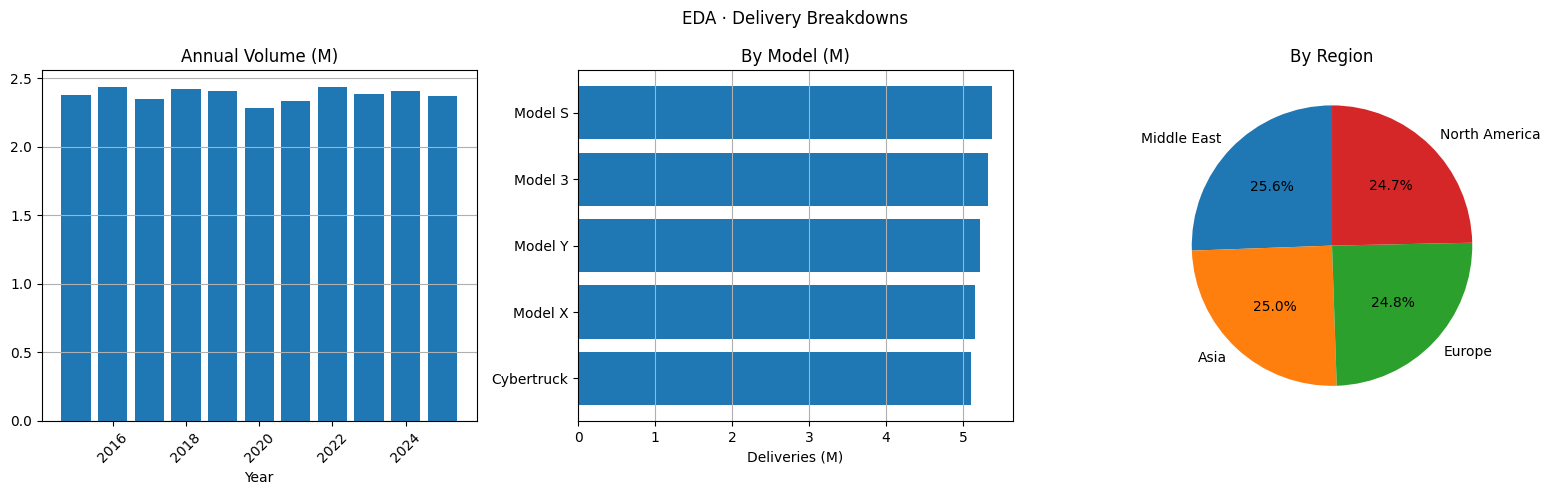

In [6]:
# ── 2.2 Deliveries by Year, Model, Region ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA · Delivery Breakdowns')

by_year  = df.groupby('Year')['Estimated_Deliveries'].sum() / 1e6
by_model = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=True) / 1e6
by_reg   = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False) / 1e6

axes[0].bar(by_year.index, by_year.values)
axes[0].set_title('Annual Volume (M)'); axes[0].set_xlabel('Year')
axes[0].tick_params(axis='x', rotation=45); axes[0].grid(True, axis='y')

bars = axes[1].barh(by_model.index, by_model.values)
axes[1].set_title('By Model (M)'); axes[1].set_xlabel('Deliveries (M)'); axes[1].grid(True, axis='x')

wedges, texts, autotexts = axes[2].pie(by_reg.values, labels=by_reg.index, autopct='%1.1f%%', startangle=90)
axes[2].set_title('By Region')

plt.tight_layout()
plt.show()

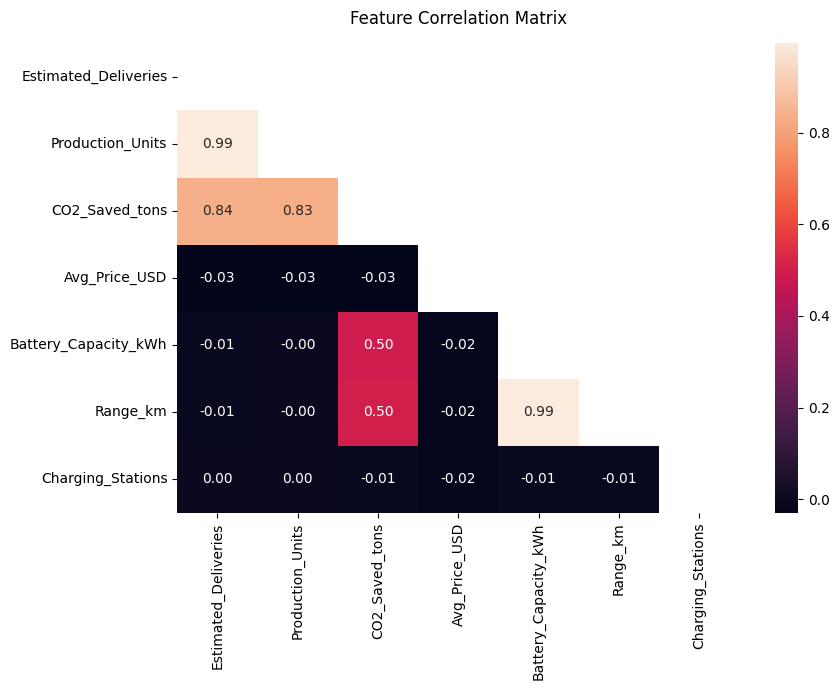

In [7]:
# ── 2.3 Correlation heatmap ──
num_cols_eda = ['Estimated_Deliveries','Production_Units','CO2_Saved_tons',
                'Avg_Price_USD','Battery_Capacity_kWh','Range_km','Charging_Stations']
corr = df[num_cols_eda].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', ax=ax)
ax.set_title('Feature Correlation Matrix', pad=14)
plt.tight_layout()
plt.show()

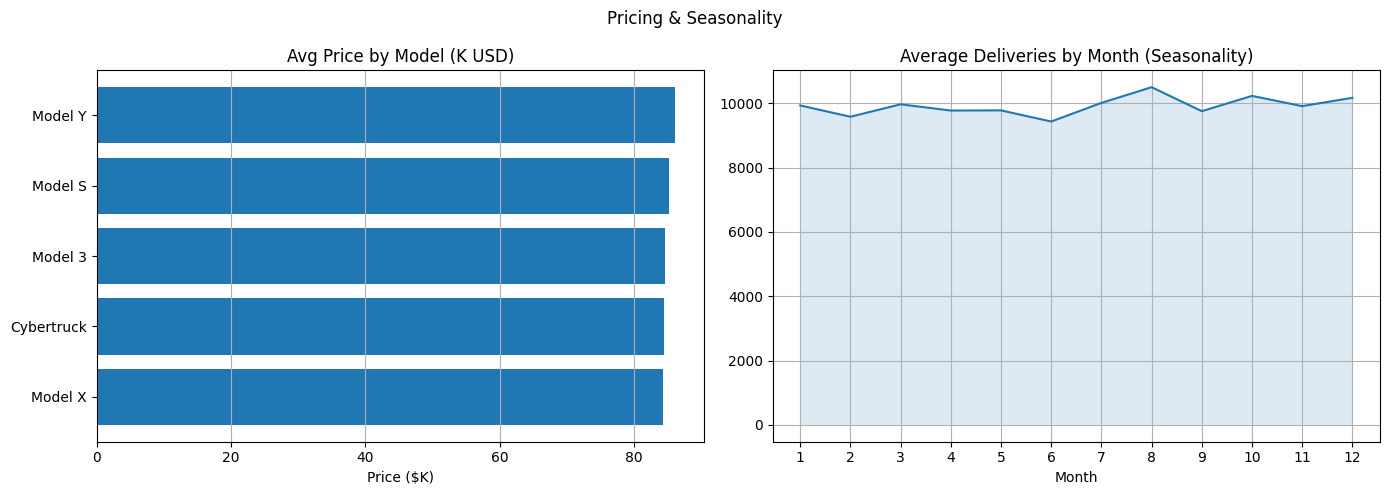

In [8]:
# ── 2.4 Price by Model & monthly seasonality ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pricing & Seasonality')

price_model = df.groupby('Model')['Avg_Price_USD'].mean().sort_values()
axes[0].barh(price_model.index, price_model.values / 1e3)
axes[0].set_title('Avg Price by Model (K USD)'); axes[0].set_xlabel('Price ($K)')
axes[0].grid(True, axis='x')

monthly = df.groupby('Month')['Estimated_Deliveries'].mean()
axes[1].plot(monthly.index, monthly.values)
axes[1].fill_between(monthly.index, monthly.values, alpha=0.15)
axes[1].set_title('Average Deliveries by Month (Seasonality)')
axes[1].set_xlabel('Month'); axes[1].set_xticks(range(1,13))
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3 · Feature Engineering

Eight new features derived from the raw data:

| Feature | Logic | Type |
|---|---|---|
| `Month_sin / Month_cos` | Cyclical encoding of month | Temporal |
| `Quarter_sin` | Cyclical encoding of quarter | Temporal |
| `Price_per_km` | Avg_Price_USD / Range_km | Derived ratio |
| `Production_efficiency` | Deliveries / Production_Units | Derived ratio |
| `CO2_per_delivery` | CO2_Saved / Deliveries | Derived ratio |
| `YoY_month` | Year − 2015 | Linear trend |
| `Is_premium` | Model ∈ {S, X} | Binary flag |
| `Is_cybertruck` | Model == Cybertruck | Binary flag |

In [9]:
def engineer_features(df):
    df = df.copy()
    df['Quarter']              = df['Month'].apply(lambda m: (m-1)//3 + 1)
    df['Month_sin']            = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_cos']            = np.cos(2 * np.pi * df['Month'] / 12)
    df['Quarter_sin']          = np.sin(2 * np.pi * df['Quarter'] / 4)
    df['Price_per_km']         = df['Avg_Price_USD'] / df['Range_km']
    df['Production_efficiency']= df['Estimated_Deliveries'] / df['Production_Units']
    df['CO2_per_delivery']     = df['CO2_Saved_tons'] / df['Estimated_Deliveries']
    df['YoY_month']            = df['Year'] - 2015
    df['Is_premium']           = df['Model'].isin(['Model S', 'Model X']).astype(int)
    df['Is_cybertruck']        = (df['Model'] == 'Cybertruck').astype(int)
    return df

df = engineer_features(df)
print(f"Features after engineering: {df.shape[1]}")
df[['Month_sin','Month_cos','Price_per_km','Production_efficiency',
    'CO2_per_delivery','YoY_month','Is_premium','Is_cybertruck']].describe()

Features after engineering: 22


,Month_sin,Month_cos,Price_per_km,Production_efficiency,CO2_per_delivery,YoY_month,Is_premium,Is_cybertruck
count,2.640000e+03,2.640000e+03,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,-1.026115e-17,-5.517472e-17,180.046065,0.932619,0.075039,5.000000,0.400000,0.200000
std,7.072407e-01,7.072407e-01,61.893503,0.037232,0.018130,3.162877,0.489991,0.400076
min,-1.000000e+00,-1.000000e+00,69.902486,0.869683,0.049500,0.000000,0.000000,0.000000
25%,-5.915064e-01,-5.915064e-01,132.532194,0.899904,0.062701,2.000000,0.000000,0.000000
50%,-6.123234e-17,-6.123234e-17,170.357466,0.932176,0.070500,5.000000,0.000000,0.000000
75%,5.915064e-01,5.915064e-01,219.097320,0.964178,0.087938,8.000000,1.000000,0.000000
max,1.000000e+00,1.000000e+00,359.377801,1.000000,0.107850,10.000000,1.000000,1.000000


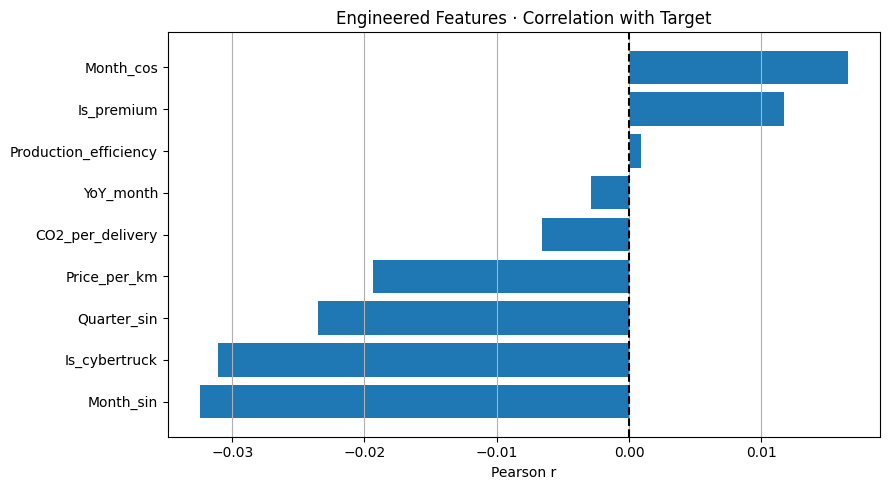

In [10]:
# Correlation of new features with target
new_feats = ['Month_sin','Month_cos','Quarter_sin','Price_per_km',
             'Production_efficiency','CO2_per_delivery','YoY_month','Is_premium','Is_cybertruck']
corrs = df[new_feats + ['Estimated_Deliveries']].corr()['Estimated_Deliveries'].drop('Estimated_Deliveries').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(corrs.index, corrs.values)
ax.axvline(0, color='black', linestyle='--')
ax.set_title('Engineered Features · Correlation with Target')
ax.set_xlabel('Pearson r')
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()

## 4 · Preprocessing & Train/Test Split

In [11]:
CAT_COLS = ['Region', 'Model', 'Source_Type']
NUM_COLS = ['Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
            'Charging_Stations', 'Production_Units', 'Quarter',
            'Month_sin', 'Month_cos', 'Quarter_sin',
            'Price_per_km', 'YoY_month', 'Is_premium', 'Is_cybertruck']
TARGET = 'Estimated_Deliveries'

X = df[CAT_COLS + NUM_COLS]
y = df[TARGET]

preprocessor = ColumnTransformer([
    ('ohe',    OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), CAT_COLS),
    ('scaler', StandardScaler(),                                                           NUM_COLS),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Target mean (train) : {y_train.mean():,.1f}  |  std : {y_train.std():,.1f}")

Train : (2112, 17)  |  Test : (528, 17)
Target mean (train) : 9,941.6  |  std : 3,954.3


## 5 · Regression Modeling (5-Fold CV)

In [12]:
models = {
    'Ridge':            Ridge(alpha=10),
    'RandomForest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'XGBoost':          xgb.XGBRegressor(n_estimators=200, random_state=42, verbosity=0, n_jobs=-1),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds  = pipe.predict(X_test)
    cv_r2  = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1).mean()
    results[name] = {
        'pipe':    pipe,
        'preds':   preds,
        'r2':      r2_score(y_test, preds),
        'rmse':    np.sqrt(mean_squared_error(y_test, preds)),
        'mae':     mean_absolute_error(y_test, preds),
        'cv_r2':   cv_r2,
    }
    print(f"{name:20s}  R²={results[name]['r2']:.4f}  RMSE={results[name]['rmse']:7.1f}  "
          f"MAE={results[name]['mae']:7.1f}  CV_R²={cv_r2:.4f}")

Ridge                 R²=0.9900  RMSE=  386.1  MAE=  308.6  CV_R²=0.9900
RandomForest          R²=0.9885  RMSE=  414.0  MAE=  327.9  CV_R²=0.9882
GradientBoosting      R²=0.9904  RMSE=  378.1  MAE=  304.3  CV_R²=0.9902
XGBoost               R²=0.9930  RMSE=  324.0  MAE=  246.0  CV_R²=0.9909


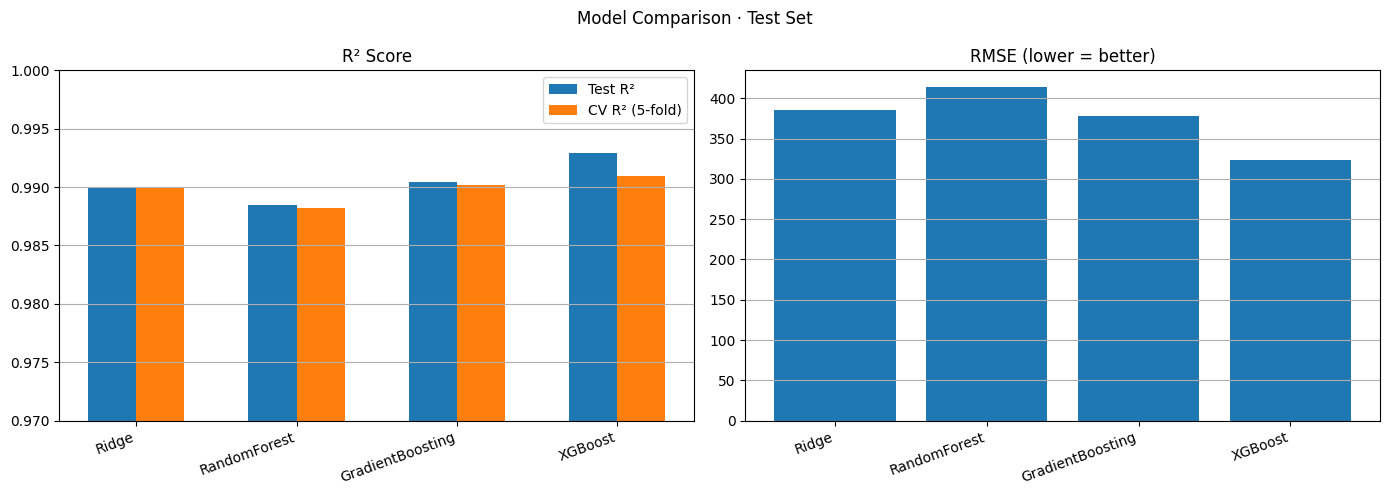

In [13]:
# ── Metric comparison chart ──
names  = list(results.keys())
r2s    = [results[n]['r2']   for n in names]
rmses  = [results[n]['rmse'] for n in names]
cv_r2s = [results[n]['cv_r2'] for n in names]

x = np.arange(len(names))
w = 0.3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison · Test Set')

axes[0].bar(x - w/2, r2s,    w, label='Test R²')
axes[0].bar(x + w/2, cv_r2s, w, label='CV R² (5-fold)')
axes[0].set_title('R² Score'); axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=20, ha='right')
axes[0].set_ylim(0.97, 1.0); axes[0].legend(); axes[0].grid(True, axis='y')

axes[1].bar(x, rmses)
axes[1].set_title('RMSE (lower = better)'); axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=20, ha='right')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

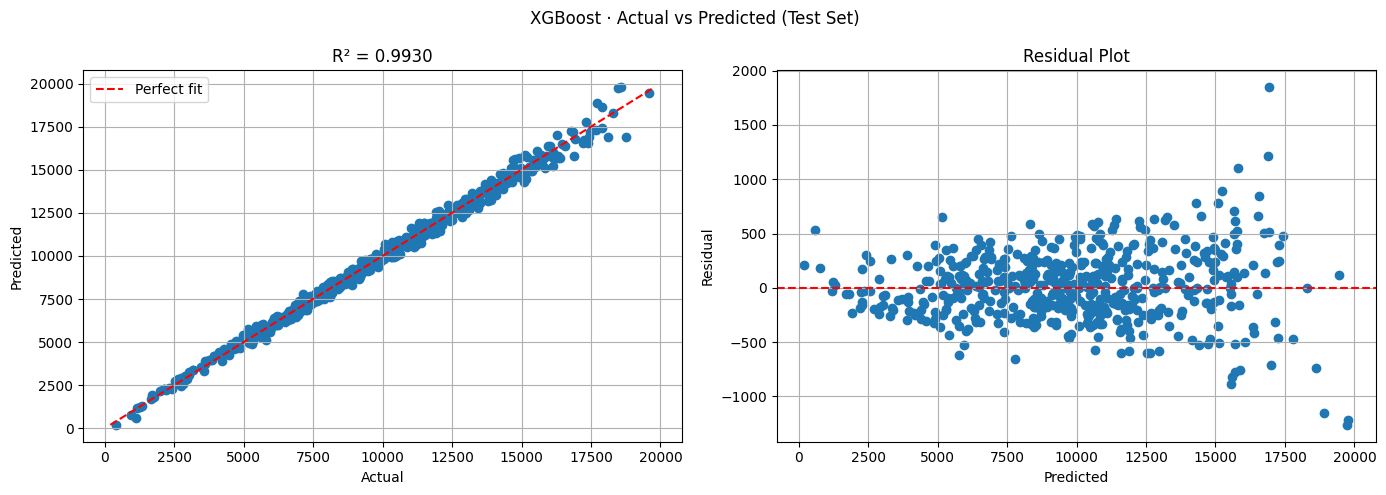

In [14]:
# ── Actual vs Predicted (best base model = XGBoost) ──
best_base = results['XGBoost']
preds = best_base['preds']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost · Actual vs Predicted (Test Set)')

axes[0].scatter(y_test, preds)
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
axes[0].plot(lims, lims, 'r--', label='Perfect fit')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'R² = {best_base["r2"]:.4f}'); axes[0].legend(); axes[0].grid(True)

residuals = y_test.values - preds
axes[1].scatter(preds, residuals)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot'); axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6 · Hyperparameter Tuning · XGBoost (RandomizedSearchCV)

In [15]:
param_dist = {
    'model__n_estimators':    [100, 200, 300],
    'model__max_depth':       [3, 5, 7],
    'model__learning_rate':   [0.05, 0.1, 0.2],
    'model__subsample':       [0.7, 0.9, 1.0],
    'model__colsample_bytree':[0.7, 0.9, 1.0],
    'model__min_child_weight':[1, 3, 5],
}

xgb_pipe = Pipeline([
    ('pre',   preprocessor),
    ('model', xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1))
])

rscv = RandomizedSearchCV(
    xgb_pipe, param_dist,
    n_iter=25, cv=3, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)
rscv.fit(X_train, y_train)

print("\n── Best Parameters ──")
for k, v in rscv.best_params_.items():
    print(f"  {k.replace('model__',''):25s}: {v}")
print(f"\nBest CV R² : {rscv.best_score_:.4f}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits

── Best Parameters ──
  subsample                : 0.7
  n_estimators             : 300
  min_child_weight         : 5
  max_depth                : 7
  learning_rate            : 0.05
  colsample_bytree         : 0.7

Best CV R² : 0.9920


In [16]:
# Evaluate tuned model
tuned_pipe  = rscv.best_estimator_
tuned_preds = tuned_pipe.predict(X_test)

tuned_r2   = r2_score(y_test, tuned_preds)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
tuned_mae  = mean_absolute_error(y_test, tuned_preds)

base_r2   = results['XGBoost']['r2']
base_rmse = results['XGBoost']['rmse']

print(f"{'Metric':<12} {'Base XGBoost':>15} {'Tuned XGBoost':>15} {'Delta':>10}")
print('-' * 55)
print(f"{'R²':<12} {base_r2:>15.4f} {tuned_r2:>15.4f} {tuned_r2-base_r2:>+10.4f}")
print(f"{'RMSE':<12} {base_rmse:>15.2f} {tuned_rmse:>15.2f} {tuned_rmse-base_rmse:>+10.2f}")
print(f"{'MAE':<12} {results['XGBoost']['mae']:>15.2f} {tuned_mae:>15.2f} {tuned_mae-results['XGBoost']['mae']:>+10.2f}")

Metric          Base XGBoost   Tuned XGBoost      Delta
-------------------------------------------------------
R²                    0.9930          0.9938    +0.0008
RMSE                  323.96          304.20     -19.76
MAE                   246.03          238.29      -7.74


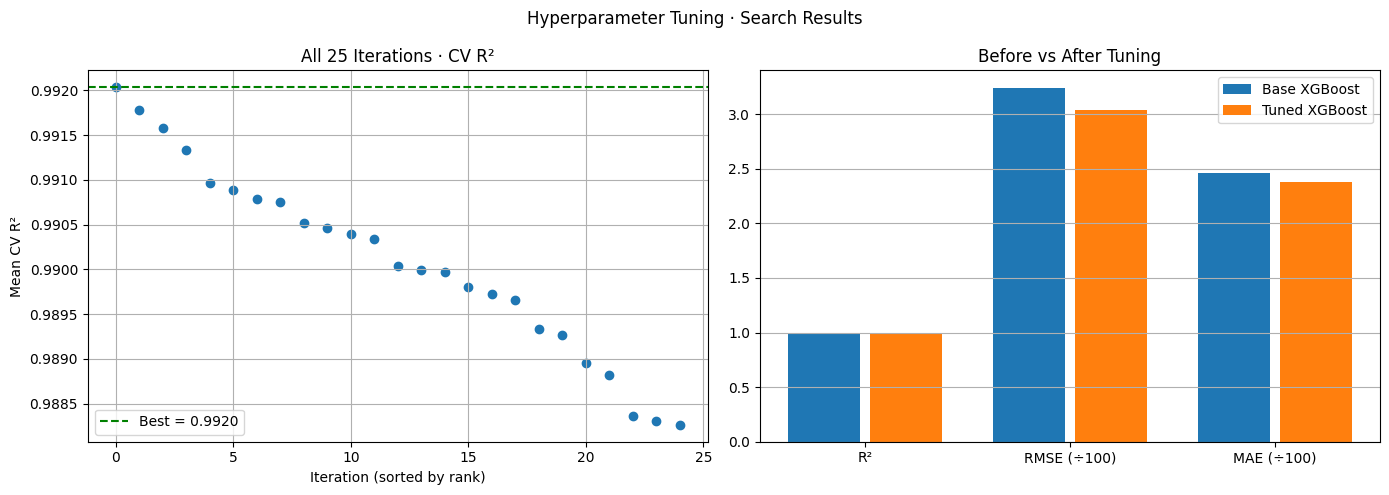

In [17]:
# CV results exploration
cv_df = pd.DataFrame(rscv.cv_results_)
cv_df = cv_df.sort_values('rank_test_score')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hyperparameter Tuning · Search Results')

axes[0].scatter(range(len(cv_df)), cv_df['mean_test_score'])
axes[0].axhline(rscv.best_score_, color='green', linestyle='--', label=f'Best = {rscv.best_score_:.4f}')
axes[0].set_title('All 25 Iterations · CV R²')
axes[0].set_xlabel('Iteration (sorted by rank)'); axes[0].set_ylabel('Mean CV R²')
axes[0].legend(); axes[0].grid(True)

metrics = ['R²', 'RMSE (÷100)', 'MAE (÷100)']
base_vals  = [base_r2, base_rmse/100, results['XGBoost']['mae']/100]
tuned_vals = [tuned_r2, tuned_rmse/100, tuned_mae/100]
x = np.arange(len(metrics))
axes[1].bar(x - 0.2, base_vals,  0.35, label='Base XGBoost')
axes[1].bar(x + 0.2, tuned_vals, 0.35, label='Tuned XGBoost')
axes[1].set_title('Before vs After Tuning'); axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
axes[1].legend(); axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

## 7 · Feature Importance

In [18]:
ohe_names  = tuned_pipe.named_steps['pre'].named_transformers_['ohe'].get_feature_names_out(CAT_COLS).tolist()
feat_names = ohe_names + NUM_COLS
importances = tuned_pipe.named_steps['model'].feature_importances_

fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)
print("Top 15 Features:")
print(fi_df.head(15).to_string(index=False))

Top 15 Features:
             feature  importance
    Production_Units    0.782522
      CO2_Saved_tons    0.115499
Battery_Capacity_kWh    0.037592
            Range_km    0.024777
       Model_Model Y    0.003764
       Region_Europe    0.003444
             Quarter    0.002902
           Month_cos    0.002792
           YoY_month    0.002525
       Avg_Price_USD    0.002323
       Model_Model X    0.001929
        Price_per_km    0.001910
       Model_Model S    0.001890
   Charging_Stations    0.001874
Region_North America    0.001814


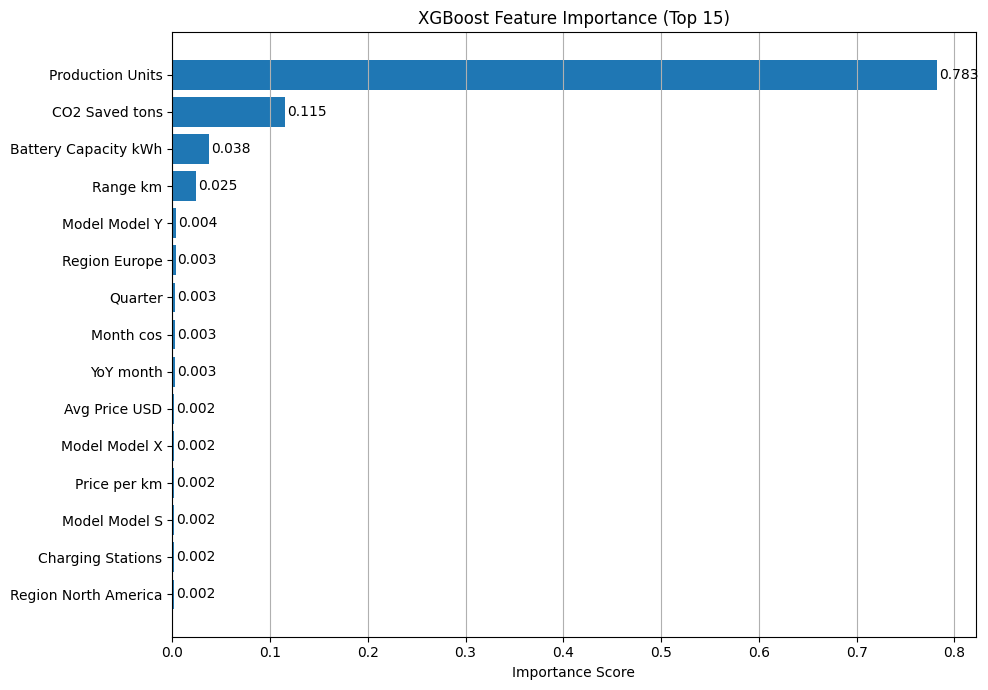

In [19]:
top_n = 15
top_fi = fi_df.head(top_n).sort_values('importance')

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_fi['feature'].str.replace('_',' '), top_fi['importance'])

for bar, val in zip(bars, top_fi['importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left')

ax.set_title(f'XGBoost Feature Importance (Top {top_n})')
ax.set_xlabel('Importance Score')
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()

## 8 · Time Series Forecasting · SARIMA(1,1,1)(1,1,1)₁₂

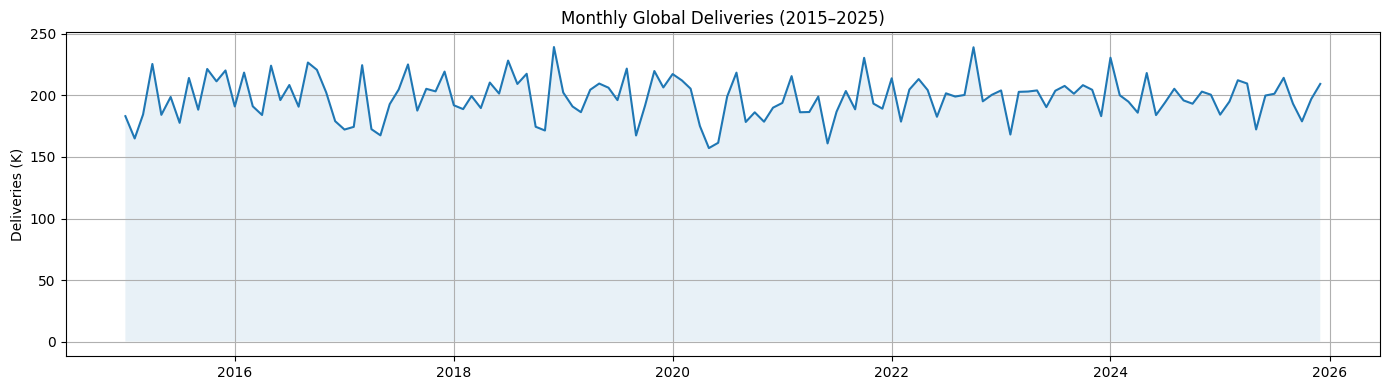

In [20]:
# Aggregate monthly global deliveries
ts_df = df.groupby(['Year','Month'])['Estimated_Deliveries'].sum().reset_index()
ts_df['Date'] = pd.to_datetime(ts_df[['Year','Month']].assign(Day=1))
ts_df = ts_df.sort_values('Date').set_index('Date')
ts_series = ts_df['Estimated_Deliveries'].asfreq('MS')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts_series.index, ts_series.values / 1e3)
ax.fill_between(ts_series.index, ts_series.values / 1e3, alpha=0.1)
ax.set_title('Monthly Global Deliveries (2015–2025)')
ax.set_ylabel('Deliveries (K)'); ax.grid(True)
plt.tight_layout()
plt.show()

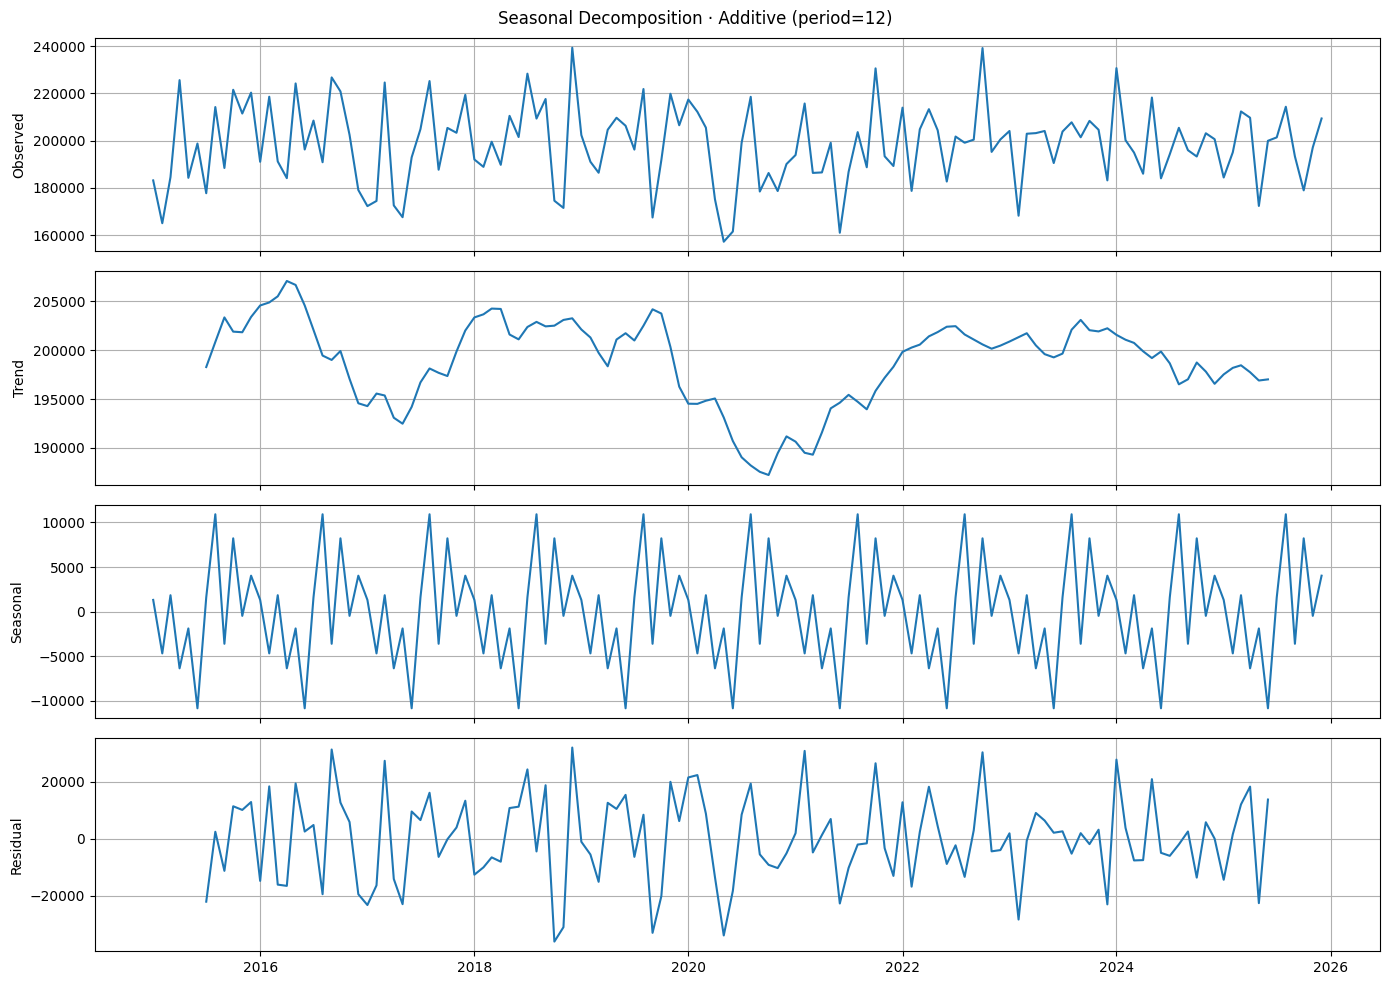

In [21]:
# Seasonal decomposition
decomp = seasonal_decompose(ts_series, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Seasonal Decomposition · Additive (period=12)')

components = [
    (decomp.observed,  'Observed'),
    (decomp.trend,     'Trend'),
    (decomp.seasonal,  'Seasonal'),
    (decomp.resid,     'Residual'),
]
for ax, (data, label) in zip(axes, components):
    ax.plot(data)
    ax.set_ylabel(label); ax.grid(True)

plt.tight_layout()
plt.show()

In [22]:
# Fit SARIMA
sarima = SARIMAX(
    ts_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                  132
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1198.559
Date:                            Sun, 17 May 2026   AIC                           2407.119
Time:                                    19:12:49   BIC                           2420.389
Sample:                                01-01-2015   HQIC                          2412.496
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0136      0.168     -0.081      0.936      -0.342       0.315
ma.L1         -0.7173      0.088   

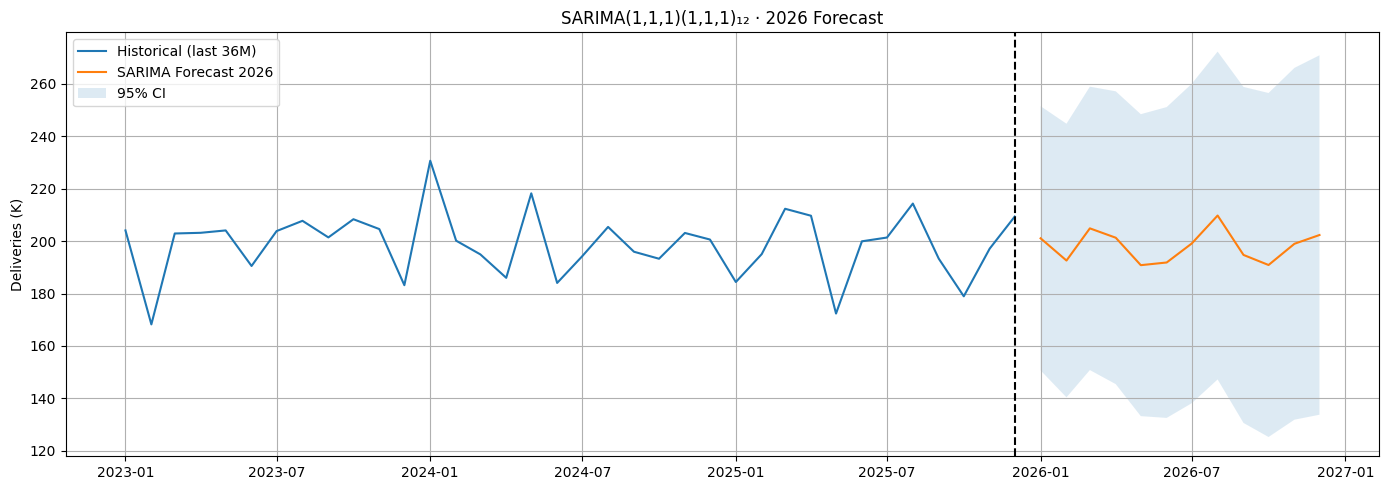

── 2026 Monthly Forecast ──
  Month  Forecast  Lower_95  Upper_95
2026-01    201096    150668    251525
2026-02    192608    140386    244831
2026-03    204893    150808    258979
2026-04    201319    145434    257203
2026-05    190842    133215    248470
2026-06    191864    132545    251183
2026-07    199112    138148    260076
2026-08    209791    147225    272356
2026-09    194750    130623    258878
2026-10    190906    125255    256558
2026-11    199006    131864    266147
2026-12    202352    133753    270951


In [23]:
# Forecast 2026
forecast = sarima_fit.get_forecast(steps=12)
fc_mean  = forecast.predicted_mean
fc_ci    = forecast.conf_int()

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
hist_plot = ts_series[-36:]

ax.plot(hist_plot.index, hist_plot.values / 1e3, label='Historical (last 36M)')

ax.plot(fc_mean.index, fc_mean.values / 1e3, label='SARIMA Forecast 2026')

ax.fill_between(fc_ci.index,
                fc_ci.iloc[:, 0] / 1e3,
                fc_ci.iloc[:, 1] / 1e3,
                alpha=0.15, label='95% CI')

ax.axvline(ts_series.index[-1], color='black', linestyle='--')
ax.set_title('SARIMA(1,1,1)(1,1,1)₁₂ · 2026 Forecast')
ax.set_ylabel('Deliveries (K)'); ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

print("── 2026 Monthly Forecast ──")
fc_table = pd.DataFrame({'Month': fc_mean.index.strftime('%Y-%m'),
                          'Forecast': fc_mean.values.round(0).astype(int),
                          'Lower_95': fc_ci.iloc[:,0].round(0).astype(int),
                          'Upper_95': fc_ci.iloc[:,1].round(0).astype(int)})
print(fc_table.to_string(index=False))